<a href="https://colab.research.google.com/github/pratyushsingh9870-arch/ML_lab/blob/main/lab_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


===== K-MEANS CLUSTERING =====


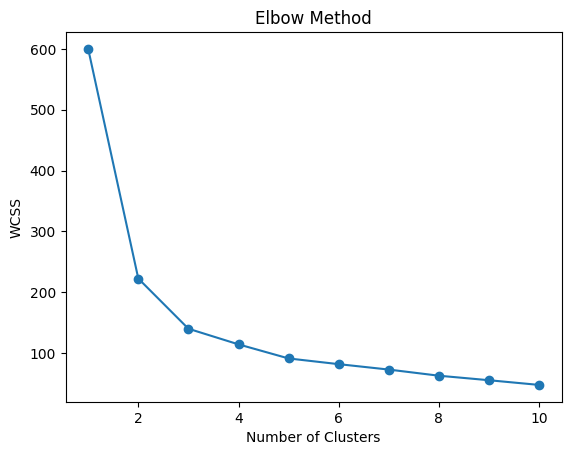

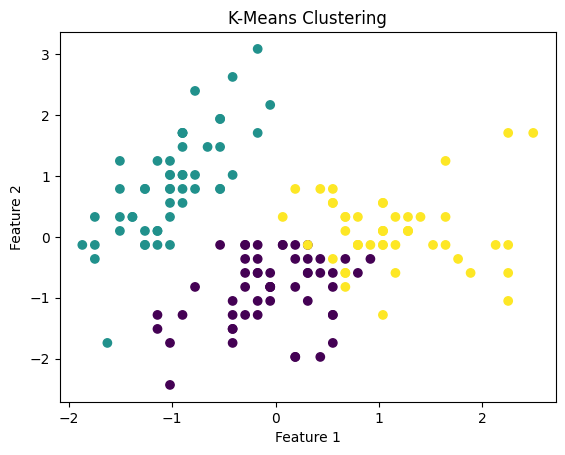


===== HIERARCHICAL CLUSTERING =====


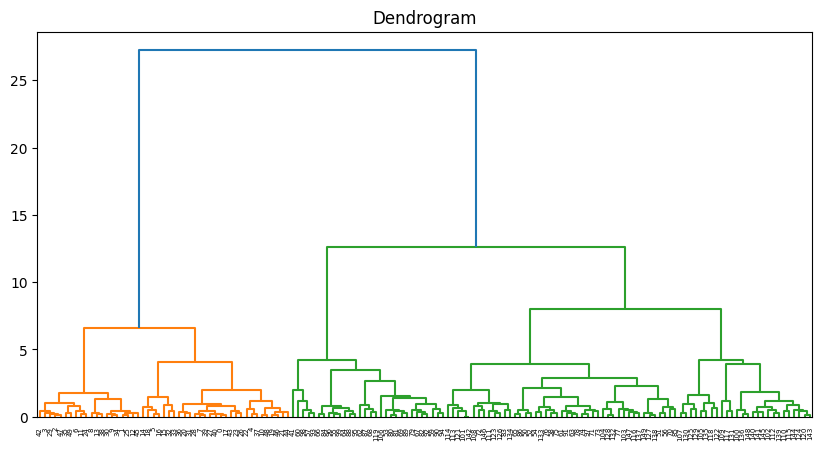

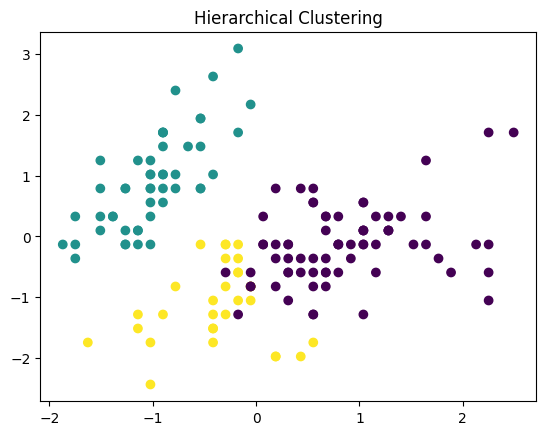


===== COMPARISON =====


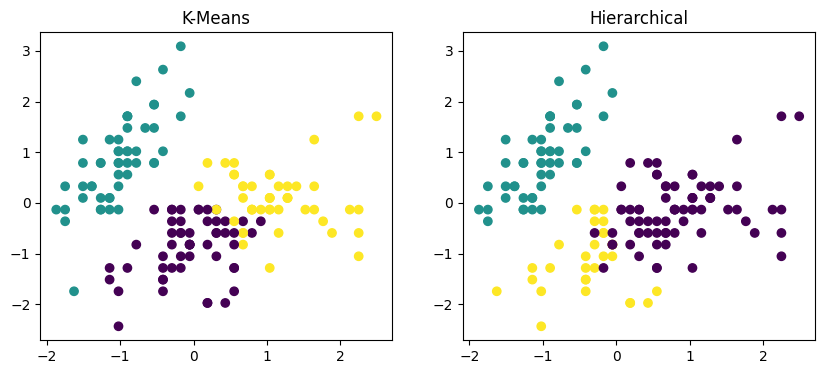

In [1]:
# ============================
# 🔹 IMPORT LIBRARIES
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# ============================
# 🔹 LOAD DATASET (AUTO)
# ============================
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)

# ============================
# 🔹 PREPROCESSING
# ============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# ============================
# 🔹 EXPERIMENT 1: K-MEANS
# ============================
print("\n===== K-MEANS CLUSTERING =====")

# Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# Apply KMeans (choose k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Visualization (2D using first 2 features)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels)
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


# ============================
# 🔹 EXPERIMENT 2: HIERARCHICAL
# ============================
print("\n===== HIERARCHICAL CLUSTERING =====")

# Dendrogram
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

# Agglomerative Clustering
hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(X_scaled)

# Visualization
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=hc_labels)
plt.title("Hierarchical Clustering")
plt.show()


# ============================
# 🔹 EXPERIMENT 3: COMPARISON
# ============================
print("\n===== COMPARISON =====")

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels)
plt.title("K-Means")

plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=hc_labels)
plt.title("Hierarchical")

plt.show()